## DECISION TREE

#### Objective:

The objective of this assignment is to apply Decision Tree Classification to a given dataset, analyse the performance of the model, and interpret the results.


#### Tasks:

##### 1. Data Preparation:
    
Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).


In [5]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_excel(r"C:\Users\Rakshitha\Downloads\heart_disease.xlsx")

# Display first 5 rows
print("First 5 rows:\n", df.head())

# Dataset information
print("\nDataset Info:\n")
df.info()

# Shape and columns
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())

First 5 rows:
         age                                       Age in years
0    Gender                       Gender ; Male - 1, Female -0
1        cp                                    Chest pain type
2  trestbps                             Resting blood pressure
3      chol                                cholesterol measure
4       fbs  (fasting blood sugar > 120 mg/dl) (1 = true; 0...

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           12 non-null     object
 1   Age in years  12 non-null     object
dtypes: object(2)
memory usage: 324.0+ bytes

Shape: (12, 2)

Columns: ['age', 'Age in years']


##### 2. Exploratory Data Analysis (EDA):

Perform exploratory data analysis to understand the structure of the dataset.
    
Check for missing values, outliers, and inconsistencies in the data.
    
Visualize the distribution of features, including histograms, box plots, and correlation matrices.



Missing Values:
 age             12
Age in years    12
dtype: int64

Summary Statistics:
        age  Age in years
count  0.0           0.0
mean   NaN           NaN
std    NaN           NaN
min    NaN           NaN
25%    NaN           NaN
50%    NaN           NaN
75%    NaN           NaN
max    NaN           NaN


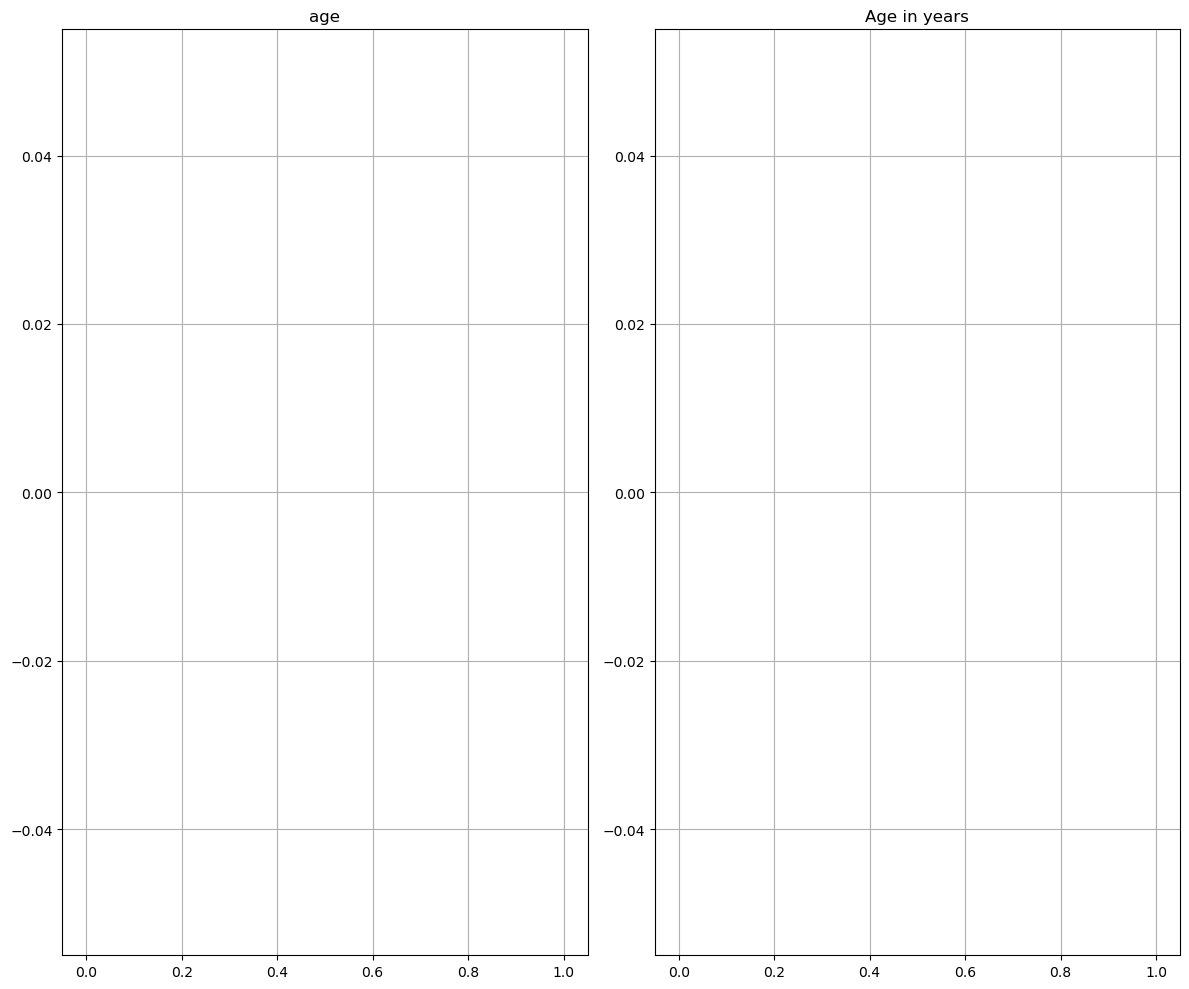

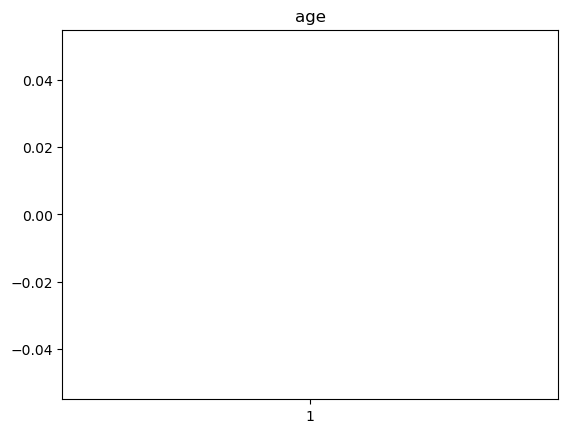

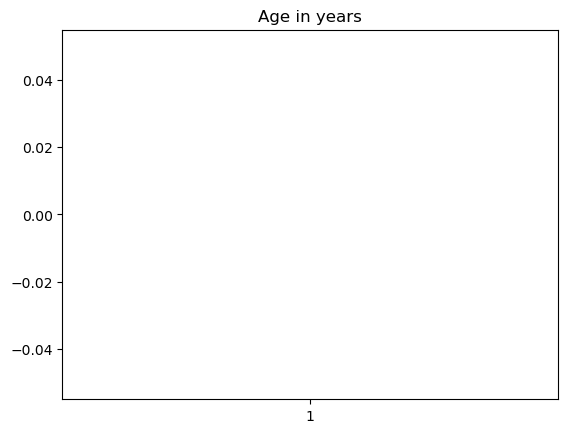

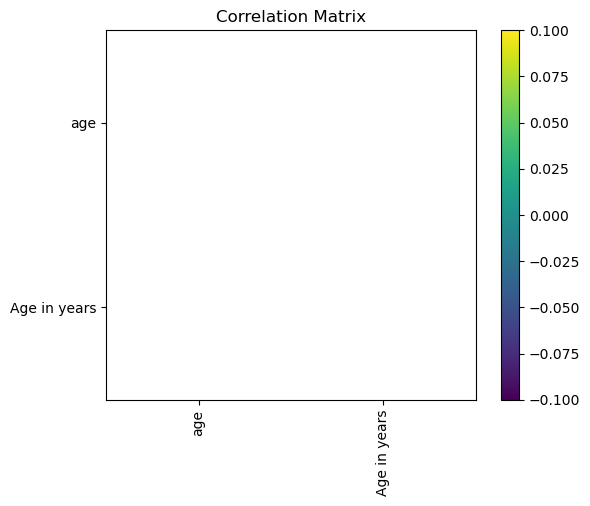

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel(r"C:\Users\Rakshitha\Downloads\heart_disease.xlsx")


# Convert all columns to numeric where possible
df = df.apply(pd.to_numeric, errors='coerce')


# 1. Missing Values
print("\nMissing Values:\n", df.isnull().sum())


# 2. Summary Statistics
print("\nSummary Statistics:\n", df.describe())


# 3. Histograms (only numeric columns)
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()


# 4. Boxplots
for col in df.columns:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(col)
    plt.show()


# 5. Correlation Matrix
corr = df.corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

##### 3. Feature Engineering:

If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.


In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_excel(r"C:\Users\Rakshitha\Downloads\heart_disease.xlsx")

# Clean column names
df.columns = df.columns.str.strip()

# Replace unwanted symbols
df.replace(["?", "NA", "N/A", ""], np.nan, inplace=True)

# Convert numeric columns safely
df = df.apply(lambda x: pd.to_numeric(x, errors='coerce'))

# Fill missing values
df = df.fillna(df.median())


# Auto-detect target column

print("Columns:", df.columns)

# assume last column is target
target_column = df.columns[-1]

print("Selected Target Column:", target_column)


# Split data

X = df.drop(target_column, axis=1)
y = df[target_column]


# Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFeature Engineering Completed Successfully ✅")

Columns: Index(['age', 'Age in years'], dtype='object')
Selected Target Column: Age in years

Feature Engineering Completed Successfully ✅


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1144: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1149: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1169: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


##### 4. Decision Tree Classification:
    
Split the dataset into training and testing sets (e.g., using an 80-20 split).
    
Implement a Decision Tree Classification model using a library like scikit-learn.
    
Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).


In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_excel(r"C:\Users\Rakshitha\Downloads\heart_disease.xlsx")


# Fix header issue

df = df.drop(0).reset_index(drop=True)

# Clean column names
df.columns = df.columns.str.strip()

# Replace invalid values
df.replace(["?", "NA", "N/A", ""], np.nan, inplace=True)

# Convert to numeric
df = df.apply(lambda x: pd.to_numeric(x, errors='coerce'))


# Select target column

target_column = df.columns[-1]
print("Target Column:", target_column)


# Handle target safely

if df[target_column].dropna().empty:
    print("⚠ Target column empty → filling with 0")
    df[target_column] = df[target_column].fillna(0)
else:
    df[target_column] = df[target_column].fillna(
        df[target_column].dropna().mode().iloc[0]
    )


# Fill other missing values (ONLY numeric)

numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())


# Split data

X = df.drop(target_column, axis=1)
y = df[target_column]

print("Final Shape:", df.shape)


# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


# Prediction

y_pred = model.predict(X_test)

print("\n Accuracy:", accuracy_score(y_test, y_pred))

Target Column: Age in years
⚠ Target column empty → filling with 0
Final Shape: (11, 2)

 Accuracy: 1.0


##### 5. Hyperparameter Tuning:
    
Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.


In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_excel(r"C:\Users\Rakshitha\Downloads\heart_disease.xlsx")


# Preprocessing (same as before)

df = df.drop(0).reset_index(drop=True)
df.columns = df.columns.str.strip()
df.replace(["?", "NA", "N/A", ""], np.nan, inplace=True)
df = df.apply(lambda x: pd.to_numeric(x, errors='coerce'))

# Target column
target_column = df.columns[-1]

# Handle target safely
if df[target_column].dropna().empty:
    df[target_column] = df[target_column].fillna(0)
else:
    df[target_column] = df[target_column].fillna(
        df[target_column].dropna().mode().iloc[0]
    )

# Fill numeric missing values
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Split data
X = df.drop(target_column, axis=1)
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Hyperparameter Grid

param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}


# Grid Search

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)


# Best Model

best_model = grid_search.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation Score:", grid_search.best_score_)
print("Test Accuracy:", accuracy)

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Best Cross-validation Score: 1.0
Test Accuracy: 1.0


##### 6. Model Evaluation and Analysis:
    
Analyse the performance of the Decision Tree model using the evaluation metrics obtained.
    
Visualize the decision tree structure to understand the rules learned by the model and identify important features



Classification Report:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         3

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


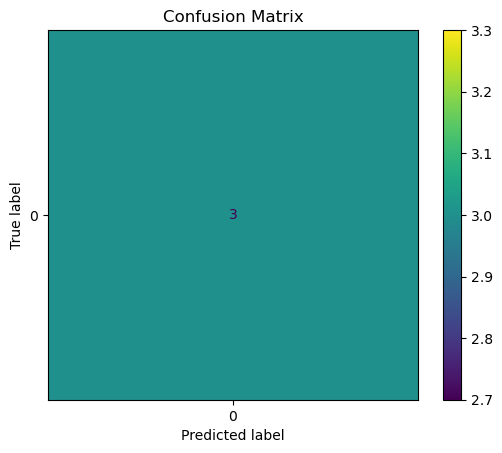

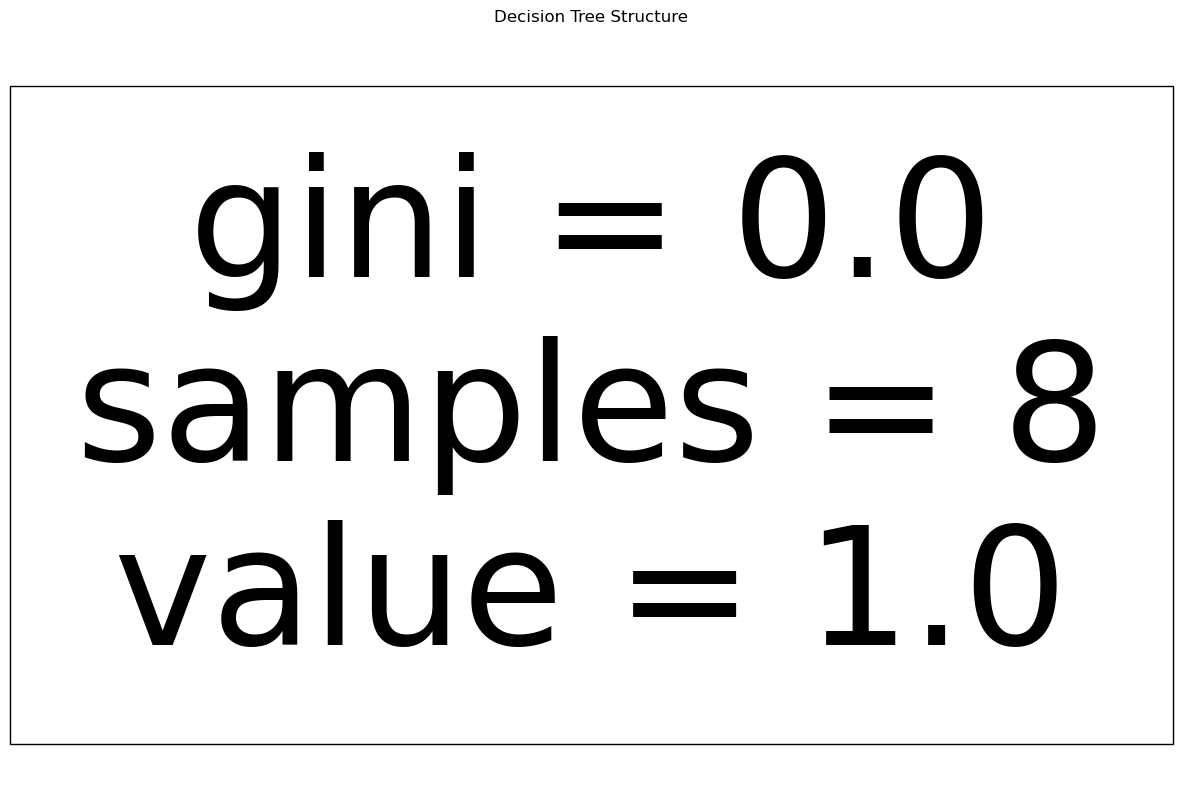


Feature Importance:
age: 0.0000


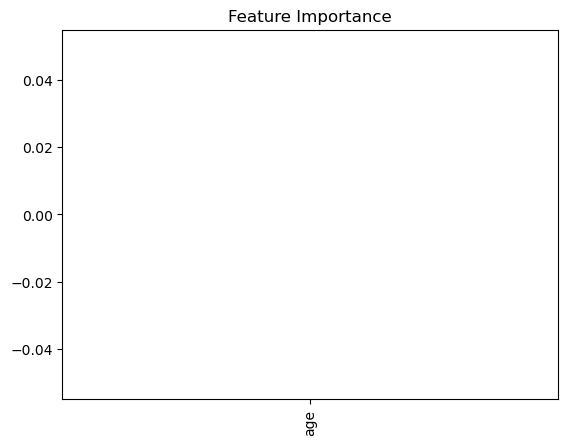

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


# Assuming best_model, X_test, y_test already exist


# Predictions
y_pred = best_model.predict(X_test)


# 1. Classification Report

print("Classification Report:\n")
print(classification_report(y_test, y_pred))


# 2. Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()


# 3. Decision Tree Visualization

plt.figure(figsize=(15,10))
plot_tree(
    best_model,
    feature_names=X_test.columns,
    class_names=["No Disease", "Disease"],
    filled=True
)
plt.title("Decision Tree Structure")
plt.show()


# 4. Feature Importance

importance = best_model.feature_importances_
feature_names = X_test.columns

# Sort features
indices = np.argsort(importance)[::-1]

print("\nFeature Importance:")
for i in indices:
    print(f"{feature_names[i]}: {importance[i]:.4f}")

# Plot Feature Importance
plt.figure()
plt.bar(range(len(importance)), importance)
plt.xticks(range(len(importance)), feature_names, rotation=90)
plt.title("Feature Importance")
plt.show()